#### The wonderful [work](https://www.kaggle.com/code/greysky/ps-s5e4-lgbm-cv-12-25-lb-12-15/notebook) of the Turkish master [Farukcan Saglam](https://www.kaggle.com/greysky/code) continues:

### One of the participants of the Kaggle community, and a brave pilot - [Alban TEISSIER](https://www.kaggle.com/albanteissier/code), 

### still in the rank of a contributor continuing what the Turkish master started, 
### further modernized the fast ship and suggested taking a look at his development:
### [fast ship that was able to overcome the ultrasonic speed](https://www.kaggle.com/code/albanteissier/podcast-lightgbm-11-95-v3) - became faster than 11.95.. 

<br/>

We, in turn, want to equip the engine of this excellent ship with 19 feats, which may help it increase its speed a little more

In [3]:
!ls /kaggle/input/pip-install-qq-scikit-learn-1-6-1

custom.css
joblib-1.4.2-py3-none-any.whl
__notebook__.ipynb
numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
__output__.json
__results__.html
scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
threadpoolctl-3.6.0-py3-none-any.whl


In [4]:
!pip install /kaggle/input/pip-install-qq-scikit-learn-1-6-1/scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl

Processing /kaggle/input/pip-install-qq-scikit-learn-1-6-1/scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
scikit-learn is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [5]:
import os, gc, psutil
import polars as pl, pandas as pd;  pd.set_option('display.max_columns', 100) 

import numpy as np

import matplotlib.pyplot as plt;    plt.style.use("seaborn-v0_8")
import seaborn as sns;              sns.set_palette("husl")

import warnings;                    warnings.simplefilter('ignore')

import lightgbm as lgb

from sklearn.preprocessing   import TargetEncoder
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse
from tqdm import tqdm


def memory_usage():
    """
    Returns the current memory usage of the process in MB.
    """
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024 * 1024)  # Convert bytes to megabytes
    return f"Memory Usage: {mem:.2f} MB"

In [6]:
original_df       = pd.read_csv("/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv")
train_df          = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv', index_col='id')
test_df           = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv',  index_col='id')
sub = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')


# Concatenate original data with synthetics ones
train_df = pd.concat([train_df, original_df], axis=0, ignore_index=True); train_df.drop_duplicates()


print("\nData Info:");                  display(train_df.info())
print("\nNumerical Features Summary:"); display(train_df.describe())
print("\nFirst 3 rows of Dataset:");    display(train_df.head(3))


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802500 entries, 0 to 802499
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 802500 non-null  object 
 1   Episode_Title                802500 non-null  object 
 2   Episode_Length_minutes       710161 non-null  float64
 3   Genre                        802500 non-null  object 
 4   Host_Popularity_percentage   802500 non-null  float64
 5   Publication_Day              802500 non-null  object 
 6   Publication_Time             802500 non-null  object 
 7   Guest_Popularity_percentage  651212 non-null  float64
 8   Number_of_Ads                802499 non-null  float64
 9   Episode_Sentiment            802500 non-null  object 
 10  Listening_Time_minutes       797105 non-null  float64
dtypes: float64(5), object(6)
memory usage: 67.3+ MB


None


Numerical Features Summary:


,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,710161.000000,802500.000000,651212.000000,802499.000000,797105.000000
mean,64.394865,59.879792,52.078083,1.358610,45.444668
std,32.983341,22.891991,28.488536,1.149546,27.140915
min,0.000000,1.300000,0.000000,0.000000,0.000000
25%,35.670000,39.460000,28.070000,0.000000,23.184220
50%,63.740000,60.060000,53.320000,1.000000,43.392270
75%,93.980000,79.560000,76.480000,2.000000,64.814620
max,325.240000,119.460000,119.910000,103.910000,119.970000



First 3 rows of Dataset:


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.8,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.9,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531


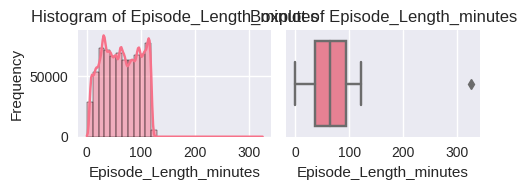


Statistics for Episode_Length_minutes:
Skewness: -0.00
Missing Values: 92339


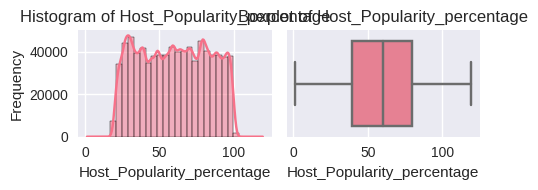


Statistics for Host_Popularity_percentage:
Skewness: 0.00
Missing Values: 0


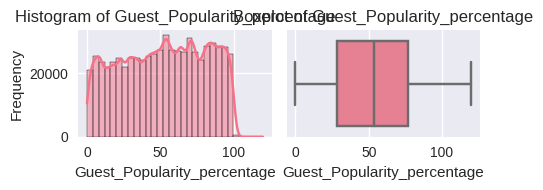


Statistics for Guest_Popularity_percentage:
Skewness: -0.10
Missing Values: 151288


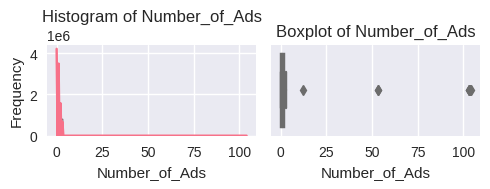


Statistics for Number_of_Ads:
Skewness: 5.66
Missing Values: 1


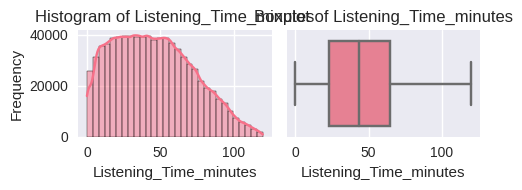


Statistics for Listening_Time_minutes:
Skewness: 0.35
Missing Values: 5395


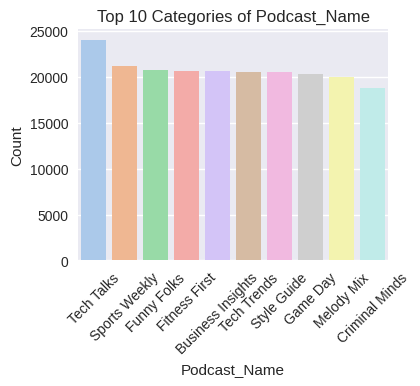

Feature: Podcast_Name
Number of Unique Values: 48
Missing Values: 0



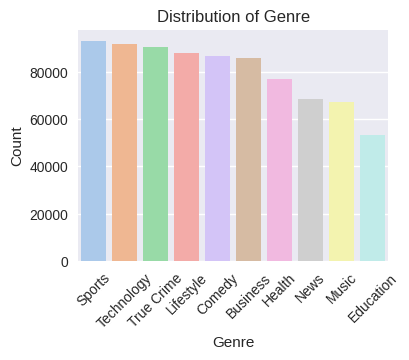

Feature: Genre
Number of Unique Values: 10
Missing Values: 0



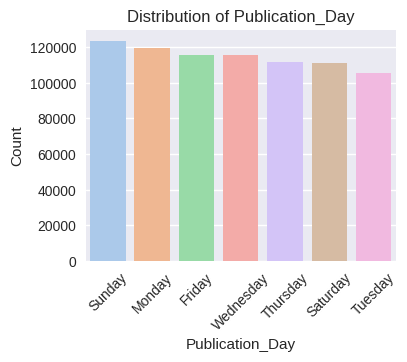

Feature: Publication_Day
Number of Unique Values: 7
Missing Values: 0



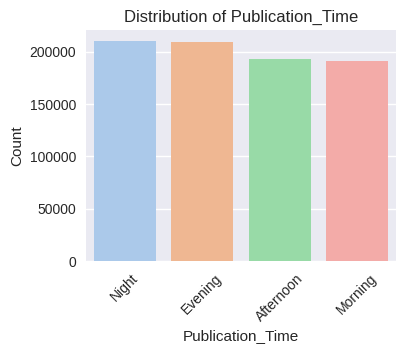

Feature: Publication_Time
Number of Unique Values: 4
Missing Values: 0



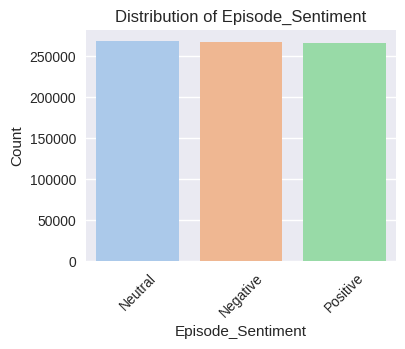

Feature: Episode_Sentiment
Number of Unique Values: 3
Missing Values: 0



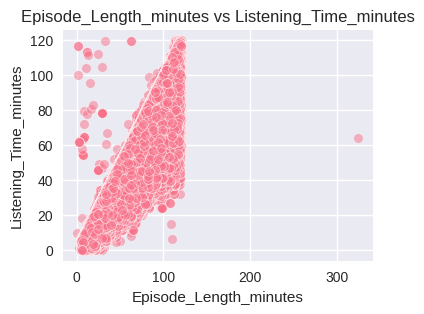

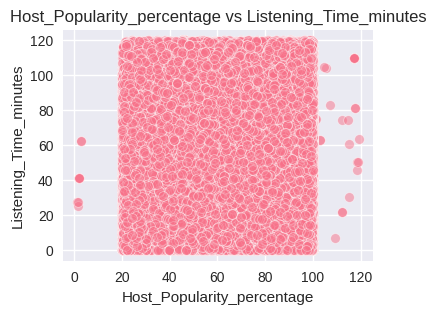

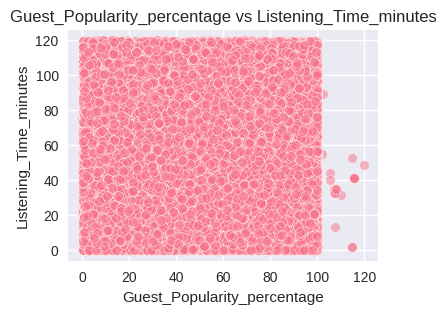

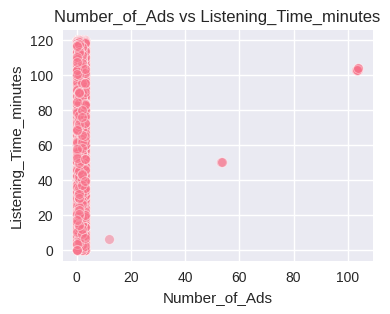

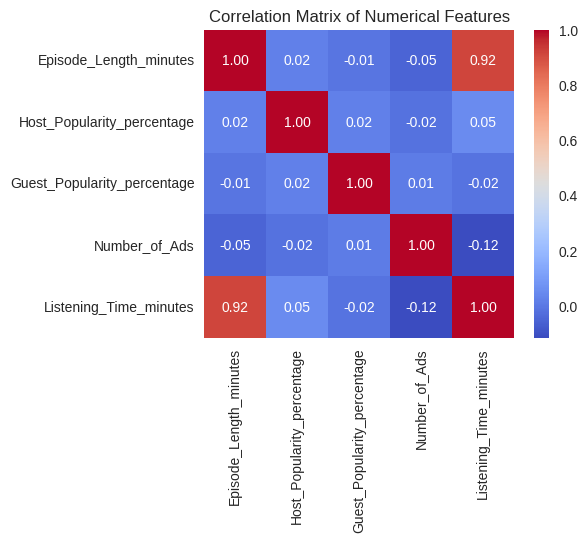

Skipping Podcast_Name: too many unique values (48)



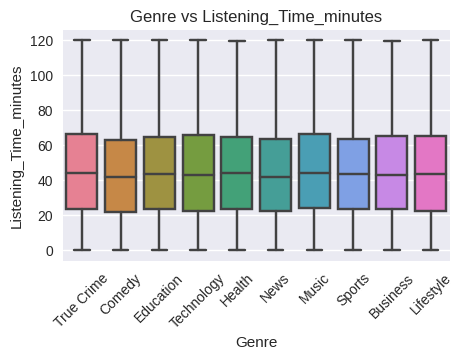

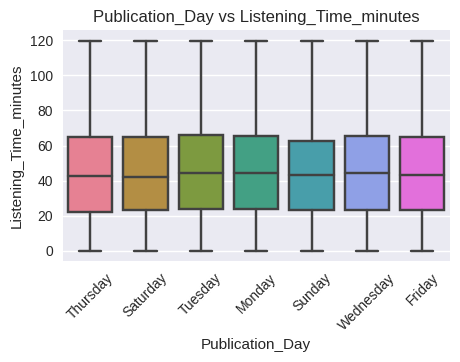

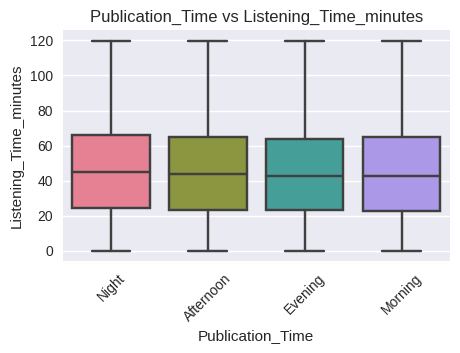

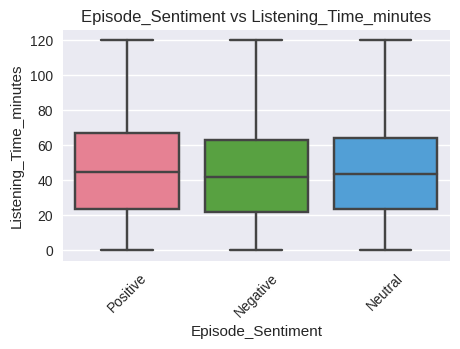

In [7]:
# Visual analitic

def numerical_distrib_analysis(data, numerical_features):
    """
    Analyzes the distribution of numerical features using histograms and boxplots.

    :param data: Pandas DataFrame containing the dataset
    :param numerical_features: List of numerical column names
    """
    for feature in numerical_features:
        plt.figure(figsize=(5, 2))

        # Histogram with KDE curve
        plt.subplot(1, 2, 1)
        sns.histplot(data[feature], kde=True, bins=30)
        plt.title(f"Histogram of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Frequency")

        # Boxplot to detect outliers
        plt.subplot(1, 2, 2)
        sns.boxplot(x=data[feature])
        plt.title(f"Boxplot of {feature}")

        plt.tight_layout()
        plt.show()

        # Additional statistics
        print(f"\nStatistics for {feature}:")
        print(f"Skewness: {data[feature].skew():.2f}")
        print(f"Missing Values: {data[feature].isnull().sum()}")


def categorical_distrib_analysis(data, categorical_features, top_n=10):
    """
    Analyzes and visualizes the distribution of categorical features.

    :param data: Pandas DataFrame containing the dataset
    :param categorical_features: List of categorical column names
    :param top_n: Max number of top categories to display for high-cardinality features
    """
    for feature in categorical_features:
        plt.figure(figsize=(4, 3))

        unique_count = data[feature].nunique()

        if unique_count > top_n:
            # Show only the top_n most frequent categories
            top_categories = data[feature].value_counts().nlargest(top_n)
            sns.barplot(x=top_categories.index, y=top_categories.values, palette="pastel")
            plt.title(f"Top {top_n} Categories of {feature}")
        else:
            # Show all categories
            sns.countplot(x=data[feature], order=data[feature].value_counts().index, palette="pastel")
            plt.title(f"Distribution of {feature}")

        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

        # Print stats
        print(f"Feature: {feature}")
        print(f"Number of Unique Values: {unique_count}")
        print(f"Missing Values: {data[feature].isnull().sum()}\n")


def numerical_correlation_analysis(data, numerical_features, target):
    """
    Analyzes and visualizes relationships between numerical features and the target.

    :param data: Pandas DataFrame containing the dataset
    :param numerical_features: List of numerical column names
    :param target: Name of the target variable
    """
    for feature in numerical_features:
        if feature != target:
            # Scatter plot: feature vs target
            plt.figure(figsize=(4, 3))
            sns.scatterplot(x=data[feature], y=data[target], alpha=0.5)
            plt.title(f"{feature} vs {target}")
            plt.xlabel(feature)
            plt.ylabel(target)
            plt.show()

    # Correlation matrix
    correlation_matrix = data[numerical_features].corr()
    plt.figure(figsize=(5, 4))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix of Numerical Features")
    plt.show()


def categorical_correlation_analysis(data, categorical_features, target, high_cardinality_threshold=10):
    """
    Visualizes categorical features against the target using boxplots.

    :param data: Pandas DataFrame containing the dataset
    :param categorical_features: List of categorical column names
    :param target: Name of the target variable
    :param high_cardinality_threshold: Max number of unique values allowed for plotting
    """
    for feature in categorical_features:
        if data[feature].nunique() <= high_cardinality_threshold:
            # Boxplot: target distribution per category
            plt.figure(figsize=(5, 3))
            sns.boxplot(x=data[feature], y=data[target], palette='husl')
            plt.title(f"{feature} vs {target}")
            plt.xlabel(feature)
            plt.ylabel(target)
            plt.xticks(rotation=45)
            plt.show()
        else:
            print(f"Skipping {feature}: too many unique values ({data[feature].nunique()})\n")


# Visual analitic in action -----------------------------------------------------


numerical_features = [
    'Episode_Length_minutes', 
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage', 
    'Number_of_Ads',
    'Listening_Time_minutes',
]
categorical_features = [
    'Podcast_Name', 
    'Genre', 
    'Publication_Day',
    'Publication_Time', 
    'Episode_Sentiment'
]

numerical_distrib_analysis       (train_df, numerical_features)
categorical_distrib_analysis     (train_df, categorical_features)
#---------------------------------
numerical_correlation_analysis   (train_df, numerical_features,   "Listening_Time_minutes")
categorical_correlation_analysis (train_df, categorical_features, 'Listening_Time_minutes')


In [8]:
def pfe(df):
    
    _dict_podc = {
        'Mystery Matters': 1.01, 'News Roundup':    1.08, 'Global News':        1.15,
        'Joke Junction'  : 1.02, 'Daily Digest':    1.09, 'Tech Talks':         1.16,
        'Study Sessions' : 1.03, 'Music Matters':   1.10, 'Sport Spot':         1.17,
        'Digital Digest' : 1.04, 'Sports Central':  1.11, 'Funny Folks':        1.18,
        'Mind & Body'    : 1.05, 'Melody Mix':      1.12, 'Sports Weekly':      1.19,
        'Fitness First'  : 1.06, 'Game Day':        1.13, 'Business Briefs':    1.20,
        'Criminal Minds' : 1.07, 'Gadget Geek':     1.14, 'Tech Trends':        1.21, 
        
        'Innovators'     : 2.01, 'Health Hour':     2.08, 'Detective Diaries':  2.15,
        'Sound Waves'    : 2.02, 'Brain Boost':     2.09, "Athlete's Arena":    2.16, 
        'Wellness Wave'  : 2.03, 'Style Guide':     2.10, 'World Watch':        2.17, 
        'Humor Hub'      : 2.04, 'Money Matters':   2.11, 'Healthy Living':     2.18, 
        'Home & Living'  : 2.05, 'Market Masters':  2.12, 'Finance Focus':      2.19,
        'Learning Lab'   : 2.06, 'Lifestyle Lounge':2.13, 'Crime Chronicles':   2.20,
        'Comedy Corner'  : 2.07, 'Life Lessons':    2.14, 'Educational Nuggets':2.21,   
        
        'Current Affairs': 3.01, 'Laugh Line':      3.02, 'True Crime Stories': 3.03, 
        'Fashion Forward': 3.04, 'Tune Time':       3.05, 'Business Insights':  3.06, "TheEnd":3.07
    }
    _dict_genr = {
        'True Crime':      4.01, 'Comedy':          4.02, 'Education':          4.03, 
        'Technology':      4.04, 'Health':          4.05, 'News':               4.06,
        'Music':           4.07, 'Sports':          4.08, 'Business':           4.09, 'Lifestyle': 4.10
    }
    _dict_week = {
        'Monday':          5.01, 'Tuesday':         5.02, 'Wednesday':          5.03, 
        'Thursday':        5.04, 'Friday':          5.05, 'Saturday':           5.06, 'Sunday': 5.07
    }    
    _dict_time = {
        'Morning':         7.01, 'Afternoon':       7.02, 'Evening':            7.03, 'Night': 3
    }
    _dict_sent = {
        'Negative':        8.01, 'Neutral':         8.02, 'Positive':           8.03
    }

    def _2_NaN(x):
        if x['x1']<0 and x['x2']<0: return -21
        if x['x1']<0              : return -3
        if               x['x2']<0: return -7
        return +7

        
    df['x1'] = df.Episode_Length_minutes;      df['x1'].fillna("NaN", inplace=True)     
    df['x2'] = df.Guest_Popularity_percentage; df['x2'].fillna("NaN", inplace=True)
    df['x3'] = df.Episode_Title       .apply(lambda x: int(x[8:]) / 100 + 10)
    df['x1'] = df['x1']               .apply(lambda x: -3 if x=="NaN" else x)
    df['x2'] = df['x2']               .apply(lambda x: -7 if x=="NaN" else x)
    df["x4"] = df                     .apply(lambda x: _2_NaN(x), axis=1)
    df['x5'] = df['Genre']            .replace(_dict_genr)
    df['x6'] = df['Podcast_Name']     .replace(_dict_podc)
    df['x7'] = df['Publication_Day']  .replace(_dict_week)
    df['x8'] = df['Publication_Time'] .replace(_dict_time)
    df['x9'] = df['Episode_Sentiment'].replace(_dict_sent)
   
    p1 = df['x1'].mean()
    p2 = df['x2'].mean()
    p3 = df['x3'].mean()
    p4 = df['x4'].mean()
    p5 = df['x5'].mean()
    p6 = df['x6'].mean()
    p7 = df['x7'].mean()
    p8 = df['x8'].mean()
    p9 = df['x9'].mean()

    df['x10'] = np.sqrt(
        (p1-df.x1)**2+
        (p2-df.x2)**2+
        (p3-df.x3)**2+
        (p4-df.x4)**2+
        (p5-df.x5)**2+
        (p6-df.x6)**2+
        (p7-df.x7)**2+
        (p8-df.x8)**2+
        (p9-df.x9)**2)

    polar_df = pl.from_pandas(df)
    
    polar_df = polar_df.with_columns(     
        _2_1 = ((pl.col('x1')-pl.col('x3'))**2+(pl.col('x2')-pl.col('x4'))**2).sqrt(),
        _2_2 = ((pl.col('x1')-pl.col('x5'))**2+(pl.col('x2')-pl.col('x6'))**2).sqrt(),
        _2_3 = ((pl.col('x1')-pl.col('x7'))**2+(pl.col('x2')-pl.col('x8'))**2).sqrt(),
        _2_4 = ((pl.col('x3')-pl.col('x5'))**2+(pl.col('x4')-pl.col('x6'))**2).sqrt(),
        _2_5 = ((pl.col('x3')-pl.col('x7'))**2+(pl.col('x4')-pl.col('x8'))**2).sqrt(),
        _2_6 = ((pl.col('x5')-pl.col('x7'))**2+(pl.col('x6')-pl.col('x8'))**2).sqrt(),
        _3_1 = ((pl.col('x1')-pl.col('x4'))**2+(pl.col('x2')-pl.col('x5'))**2+(pl.col('x3')-pl.col('x6'))**2).sqrt(),
        _3_2 = ((pl.col('x1')-pl.col('x7'))**2+(pl.col('x2')-pl.col('x8'))**2+(pl.col('x3')-pl.col('x9'))**2).sqrt(),
        _3_3 = ((pl.col('x4')-pl.col('x7'))**2+(pl.col('x5')-pl.col('x8'))**2+(pl.col('x6')-pl.col('x9'))**2).sqrt(),
        _4_1 = ((pl.col('x1')-pl.col('x5'))**2+(pl.col('x2')-pl.col('x6'))**2+(pl.col('x3')-pl.col('x7'))**2+(pl.col('x4')-pl.col('x8'))**2).sqrt(),)
                
    df = polar_df.to_pandas()

    p1 = df['_2_1'].mean()
    p2 = df['_2_2'].mean()
    p3 = df['_2_3'].mean()
    p4 = df['_2_4'].mean()
    p5 = df['_2_5'].mean()
    p6 = df['_2_6'].mean()
    p7 = df['_3_1'].mean()
    p8 = df['_3_2'].mean()
    p9 = df['_3_3'].mean()
    p0 = df['_4_1'].mean()

    df['_x_11'] = np.sqrt(
        (p1-df._2_1)**2+
        (p2-df._2_2)**2+
        (p3-df._2_3)**2+
        (p4-df._2_4)**2+
        (p5-df._2_5)**2+
        (p6-df._2_6)**2+
        (p7-df._3_1)**2+
        (p8-df._3_2)**2+
        (p9-df._3_3)**2+
        (p0-df._4_1)**2)

    return df

In [9]:
print("Preparing managing null values..")

train_df = pfe(train_df)
test_df  = pfe(test_df)

print("Missing Values per Column:"); print(train_df.isnull().sum())
print("Missing Values per Column:"); print(test_df .isnull().sum())

# Replacing null values by median
train_df['Episode_Length_minutes'].fillna(train_df['Episode_Length_minutes'].median(), inplace=True)
test_df ['Episode_Length_minutes'].fillna(train_df['Episode_Length_minutes'].median(), inplace=True)

# Null values could mean no guest 
train_df['Guest_Popularity_percentage'].fillna(train_df['Guest_Popularity_percentage'].median(), inplace=True)
test_df ['Guest_Popularity_percentage'].fillna(test_df ['Guest_Popularity_percentage'].median(), inplace=True)


train_df = train_df[train_df['Number_of_Ads']<10] # Deleting outliers 


train_df.dropna(inplace=True)

Preparing managing null values..
Missing Values per Column:
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          92339
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    151288
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes           5395
x1                                  0
x2                                  0
x3                                  0
x4                                  0
x5                                  0
x6                                  0
x7                                  0
x8                                  0
x9                                  0
x10                                 0
_2_1                                0
_2_2                                0
_2_3                                0
_2_4                        

In [10]:
from sklearn.preprocessing import LabelEncoder

# Encoder for categorical data
label_encoders = {col: LabelEncoder() for col in categorical_features}

# Apply LabelEncoder to each categorical column
for col in categorical_features:
    train_df[col] = label_encoders[col].fit_transform(train_df[col])
    test_df [col] = label_encoders[col]    .transform(test_df [col])

    # Converting to category type 
    train_df[col] = train_df[col].astype('category')
    test_df [col] = test_df [col].astype('category')

gc.collect()

# creating most relevant feature 
train_df['Episode_Num'] = train_df['Episode_Title'].str[8:].astype('category')
test_df ['Episode_Num'] = test_df ['Episode_Title'].str[8:].astype('category')

train_df = train_df.drop(columns=['Episode_Title'])
test_df  = test_df .drop(columns=['Episode_Title'])

display(train_df['Podcast_Name'].nunique(), train_df.head())

48

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,_2_1,_2_2,_2_3,_2_4,_2_5,_2_6,_3_1,_3_2,_3_3,_4_1,_x_11,Episode_Num
0,34,63.74,9,74.81,4,3,53.32,0.0,2,31.41998,-3.00,-7.00,10.98,-21,4.01,1.01,5.04,3.00,8.03,80.284036,19.784853,10.644257,12.831274,23.087248,24.724150,2.240759,23.337116,13.166021,26.988555,26.918094,142.071508,98
1,24,119.80,1,66.95,2,0,75.95,2.0,0,88.01241,119.80,75.95,10.26,7,4.02,1.02,5.06,7.02,8.01,72.331234,129.433821,137.911252,133.852951,8.642800,5.200038,6.089466,134.101240,133.871860,7.850076,138.009252,147.541544,26
2,40,73.90,2,69.97,5,1,8.97,0.0,0,44.92531,73.90,8.97,10.16,7,4.03,1.03,5.02,7.03,8.01,36.566007,63.770436,70.319702,68.907315,8.556740,5.140088,6.081127,67.700595,68.940848,7.851166,70.507312,15.402227,16
3,10,67.17,8,57.22,1,2,78.70,2.0,2,46.27824,67.17,78.70,10.45,7,4.04,1.04,5.01,7.01,8.03,39.414702,91.422363,100.082329,94.885835,8.752697,5.440009,6.048289,96.348807,94.916690,7.851185,100.230066,54.056871,45
4,31,110.51,3,80.07,1,0,58.68,3.0,1,75.61031,110.51,58.68,10.86,7,4.05,1.05,5.01,7.02,8.02,56.865108,112.253930,121.057625,117.469169,9.043152,5.850034,6.046693,117.452089,117.503494,7.833384,121.198892,106.629897,86


In [ ]:
from tqdm import tqdm
from itertools import combinations

columns_to_encode = [
    'Episode_Length_minutes', 
    'Episode_Num', 
    'Host_Popularity_percentage', 
    'Number_of_Ads', 
    'Episode_Sentiment', 
    'Publication_Day', 
    'Publication_Time',
    'Genre',
    'Guest_Popularity_percentage'
]

pair_size = [2, 3, 4]


for r in pair_size: 
    combinations_list = list(combinations(columns_to_encode,r))
    batch_size = 20

    print('\n pair_size:', r, '\n')
    
    for i in range(0, len(combinations_list), batch_size):
        
        batch = combinations_list[i : i +batch_size]
        
        for cols in tqdm(batch):
            new_col_name = '_'.join(cols)

            train_df[new_col_name] = train_df[list(cols)].astype(str).agg('_'.join, axis=1) 
            test_df [new_col_name] = test_df [list(cols)].astype(str).agg('_'.join, axis=1) 
            test_df [new_col_name] = test_df [new_col_name].astype('category')
            train_df[new_col_name] = train_df[new_col_name].astype('category')
            
        gc.collect()
        
        print(f"Memory usage: {train_df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
        print(f"Total number of columns: {len(train_df.columns)}")

    print("~"*19)


 pair_size: 2 



100%|██████████| 20/20 [01:58<00:00,  5.92s/it]


Memory usage: 504.21 MB
Total number of columns: 52


100%|██████████| 16/16 [01:28<00:00,  5.53s/it]


Memory usage: 608.06 MB
Total number of columns: 68
~~~~~~~~~~~~~~~~~~~

 pair_size: 3 



...

100%|██████████| 4/4 [00:26<00:00,  6.71s/it]


Memory usage: 3405.69 MB
Total number of columns: 152
~~~~~~~~~~~~~~~~~~~

 pair_size: 4 



100%|██████████| 20/20 [03:00<00:00,  9.02s/it]


Memory usage: 4758.79 MB
Total number of columns: 172


 65%|██████▌   | 13/20 [02:04<01:07,  9.63s/it]

### Models 

In [ ]:
X = train_df.drop(columns=['Listening_Time_minutes'])
y = train_df['Listening_Time_minutes']

In [ ]:
X

In [ ]:
gc.collect()

N_SPLITS =    7  
cv = KFold(N_SPLITS, random_state=42, shuffle=True)
y_pred = np.zeros(len(sample_submission))

for idx_train, idx_valid in cv.split(X, y):
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]
    X_test = test_df[X.columns].copy()

    encoded_columns = train_df.columns[30:] # original: train_df.columns[11:] + 19 new feats
    encoder = TargetEncoder(random_state=42)

    X_train[encoded_columns] = encoder.fit_transform(X_train[encoded_columns], y_train)  
    X_valid[encoded_columns] = encoder.transform(X_valid[encoded_columns])
    X_test [encoded_columns] = encoder.transform(X_test[encoded_columns])

    model = RandomForestRegressor(n_estimators=1000, max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=42, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None)


    model.fit()

    pred = model.predict(X_valid)
    print(np.sqrt(mse(red)))

    y_pred += model.predict(X_test)

pred_rfr = y_pred / N_SPLITS

In [ ]:
sub['Listening_Time_minutes'] = pred_rfr
sub.to_csv('submission.csv', index=False)
sub